In [1]:
"""
ln(PRICE)=-9.53*** + 0.69∙ln(GH/s)*** – 0.98∙ln(COINS_PER_MIN)*** +7.46∙(ALGO)***
Significant Variables
Computational Power : GH/s
COINS_PER_Min : Block Reward/Time between Blocks
ALGO : SHA-256 (1) or anything else (Scrypt)
"""
import requests
import numpy as np
import pandas as pd
import datetime
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statistics

from io import BytesIO
import statsmodels.api as sm

# NBER recessions
from pandas_datareader.data import DataReader

In [2]:
def expo_vol(prices):
    ma = []
    alpha = 2/(len(prices) + 1)
    ma.append(prices[0]**2)
    for i in range(1,len(prices),1) :
        ma.append(ma[i-1] +alpha*(prices[i]**2-ma[i-1]))

    return ma 

In [3]:
MarketPriceData = requests.get("https://api.blockchain.info/charts/market-price?timespan=10year&format=json&sampled=false")  # BTC Price is USD for 1 year
MarketPriceData.status_code

MarketPriceData_df = pd.DataFrame(MarketPriceData.json())
MarketPriceData_df['Market Price'] = [MarketPriceData_df['values'][i]['y'] for i in range(0,len(MarketPriceData_df),1)]
MarketPriceData_df['TimeStamp'] = [datetime.datetime.fromtimestamp(MarketPriceData_df['values'][i]['x']) for i in range(0,len(MarketPriceData_df),1)]
MarketPriceData_df['EWMA_Vol'] = expo_vol(MarketPriceData_df['Market Price'])
MarketPriceData_df

,status,name,unit,period,description,values,Market Price,TimeStamp,EWMA_Vol
0,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1331424000, 'y': 4.95}",4.95,2012-03-11,2.450250e+01
1,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1331510400, 'y': 4.98}",4.98,2012-03-12,2.450266e+01
2,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1331596800, 'y': 5.07}",5.07,2012-03-13,2.450332e+01
3,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1331683200, 'y': 5.42}",5.42,2012-03-14,2.450599e+01
4,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1331769600, 'y': 5.45}",5.45,2012-03-15,2.450884e+01
...,...,...,...,...,...,...,...,...,...
3646,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1646438400, 'y': 39141.25}",39141.25,2022-03-05,5.079381e+08
3647,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1646524800, 'y': 39399.58}",39399.58,2022-03-06,5.085101e+08
3648,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1646611200, 'y': 38407.69}",38407.69,2022-03-07,5.090395e+08
3649,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1646697600, 'y': 38032.5}",38032.50,2022-03-08,5.095528e+08


In [4]:
HashrateData =  requests.get("https://api.blockchain.info/charts/hash-rate?timespan=10years&format=json&sampled=false") #Computational Power in GH/s for 1 year
HashrateData.status_code

HashrateData_df = pd.DataFrame(HashrateData.json())

HashrateData_df['HashRate']  = [HashrateData_df['values'][i]['y'] for i in range(0,len(HashrateData_df),1)] 
HashrateData_df['TimeStamp'] = [datetime.datetime.fromtimestamp(HashrateData_df['values'][i]['x']) for i in range(0,len(HashrateData_df),1)]
HashrateData_df  

,status,name,unit,period,description,values,HashRate,TimeStamp
0,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1331424000, 'y': 9.89722287527119}",9.897223e+00,2012-03-11
1,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1331510400, 'y': 12.5761704204574}",1.257617e+01,2012-03-12
2,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1331596800, 'y': 11.3111118574528}",1.131111e+01,2012-03-13
3,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1331683200, 'y': 10.2692989232137}",1.026930e+01,2012-03-14
4,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1331769600, 'y': 9.59956203691717}",9.599562e+00,2012-03-15
...,...,...,...,...,...,...,...,...
3645,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1646352000, 'y': 190365286.64550212}",1.903653e+08,2022-03-04
3646,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1646438400, 'y': 168452735.66472492}",1.684527e+08,2022-03-05
3647,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1646524800, 'y': 179409011.15511352}",1.794090e+08,2022-03-06
3648,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1646611200, 'y': 202691096.5721893}",2.026911e+08,2022-03-07


In [5]:
BlockDifficulty = requests.get("https://api.blockchain.info/charts/difficulty?timespan=10years&format=json&sampled=false") #Relative Difficulty of mining
BlockDifficulty.status_code  

BlockDifficulty_df = pd.DataFrame(BlockDifficulty.json()) 

BlockDifficulty_df['Difficulty'] = [BlockDifficulty_df['values'][i]['y'] for i in range(0,len(BlockDifficulty_df),1) ]   
BlockDifficulty_df['Timestamp'] =  [datetime.datetime.fromtimestamp(BlockDifficulty_df['values'][i]['x']) for i  in range(0,len(BlockDifficulty_df),1) ]
BlockDifficulty_df

,status,name,unit,period,description,values,Difficulty,Timestamp
0,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1331424000, 'y': 1496978.59502557}",1.496979e+06,2012-03-11
1,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1331510400, 'y': 1496978.59502557}",1.496979e+06,2012-03-12
2,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1331596800, 'y': 1496978.59502557}",1.496979e+06,2012-03-13
3,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1331683200, 'y': 1496978.59502557}",1.496979e+06,2012-03-14
4,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1331769600, 'y': 1496978.59502557}",1.496979e+06,2012-03-15
...,...,...,...,...,...,...,...,...
3645,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1646352000, 'y': 27550332084344.0}",2.755033e+13,2022-03-04
3646,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1646438400, 'y': 27550332084344.0}",2.755033e+13,2022-03-05
3647,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1646524800, 'y': 27550332084344.0}",2.755033e+13,2022-03-06
3648,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1646611200, 'y': 27550332084344.0}",2.755033e+13,2022-03-07


In [6]:
MinersRevenue = requests.get("https://api.blockchain.info/charts/miners-revenue?timespan=10years&format=json&sampled=false")   #Miners Revenue : Total value in USD of coinbase block rewards and transaction fees paid to miners.

MinersRevenue.status_code  

MinersRevenue_df = pd.DataFrame(MinersRevenue.json())

MinersRevenue_df['MinerRevenue'] = [MinersRevenue_df['values'][i]['y'] for i in range(0,len(MinersRevenue_df),1) ]   
MinersRevenue_df['Timestamp'] =  [datetime.datetime.fromtimestamp(MinersRevenue_df['values'][i]['x']) for i  in range(0,len(MinersRevenue_df),1) ]
MinersRevenue_df

,status,name,unit,period,description,values,MinerRevenue,Timestamp
0,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1331424000, 'y': 36645.371567244}",3.664537e+04,2012-03-11
1,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1331510400, 'y': 50317.7372087016}",5.031774e+04,2012-03-12
2,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1331596800, 'y': 52792.9346141847}",5.279293e+04,2012-03-13
3,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1331683200, 'y': 45828.1974228738}",4.582820e+04,2012-03-14
4,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1331769600, 'y': 34082.711867166}",3.408271e+04,2012-03-15
...,...,...,...,...,...,...,...,...
3645,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1646352000, 'y': 36333926.06318503}",3.633393e+07,2022-03-04
3646,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1646438400, 'y': 31045143.393329486}",3.104514e+07,2022-03-05
3647,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1646524800, 'y': 32347699.625522234}",3.234770e+07,2022-03-06
3648,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1646611200, 'y': 35836828.333603054}",3.583683e+07,2022-03-07


split data:
pre 2015
post 2015
fitness of model check
regime change
vol of prices : trend
if the model holds: we can conclude that price beahviour is similar to Commodity

In [7]:
df1 = MinersRevenue_df[['Timestamp','MinerRevenue']].merge(BlockDifficulty_df[['Timestamp','Difficulty']], how='inner',on='Timestamp')
df1 = df1.rename(columns={'Timestamp':'TimeStamp'})
df2 = MarketPriceData_df[['TimeStamp','Market Price']].merge(HashrateData_df[['TimeStamp','HashRate']], how='inner',on='TimeStamp')

df3 = df1.merge(df2,how='inner',on='TimeStamp')
df3['MinerRevenue(BTC)'] =  df3["MinerRevenue"].div(df3["Market Price"].values) 
   
df3

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC)
0,2012-03-11,3.664537e+04,1.496979e+06,4.95,9.897223e+00,7403.105367
1,2012-03-12,5.031774e+04,1.496979e+06,4.98,1.257617e+01,10103.963295
2,2012-03-13,5.279293e+04,1.496979e+06,5.07,1.131111e+01,10412.807616
3,2012-03-14,4.582820e+04,1.496979e+06,5.42,1.026930e+01,8455.386978
4,2012-03-15,3.408271e+04,1.496979e+06,5.45,9.599562e+00,6253.708599
...,...,...,...,...,...,...
3645,2022-03-04,3.633393e+07,2.755033e+13,42464.40,1.903653e+08,855.632626
3646,2022-03-05,3.104514e+07,2.755033e+13,39141.25,1.684527e+08,793.156667
3647,2022-03-06,3.234770e+07,2.755033e+13,39399.58,1.794090e+08,821.016357
3648,2022-03-07,3.583683e+07,2.755033e+13,38407.69,2.026911e+08,933.063882


In [8]:
import yfinance as yf
data = yf.download("^GSPC", start=min(df3['TimeStamp']), end= max(df3['TimeStamp']))

data = data.reset_index(drop=False)
data

[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-03-12,1370.780029,1373.040039,1366.689941,1371.089966,1371.089966,3081870000
1,2012-03-13,1371.920044,1396.130005,1371.920044,1395.949951,1395.949951,4386470000
2,2012-03-14,1395.949951,1399.420044,1389.969971,1394.280029,1394.280029,4502280000
3,2012-03-15,1394.170044,1402.630005,1392.780029,1402.599976,1402.599976,4271650000
4,2012-03-16,1402.550049,1405.880005,1401.469971,1404.170044,1404.170044,5163950000
...,...,...,...,...,...,...,...
2509,2022-03-01,4363.140137,4378.450195,4279.540039,4306.259766,4306.259766,4679400000
2510,2022-03-02,4322.560059,4401.479980,4322.560059,4386.540039,4386.540039,4409090000
2511,2022-03-03,4401.310059,4416.779785,4345.560059,4363.490234,4363.490234,4062080000
2512,2022-03-04,4342.120117,4342.120117,4284.979980,4328.870117,4328.870117,4558250000


In [9]:
CorrData = df3[['TimeStamp','Market Price']].merge(data[['Date','Adj Close']], how='inner',left_on='TimeStamp', right_on='Date')
CorrData

,TimeStamp,Market Price,Date,Adj Close
0,2012-03-12,4.98,2012-03-12,1371.089966
1,2012-03-13,5.07,2012-03-13,1395.949951
2,2012-03-14,5.42,2012-03-14,1394.280029
3,2012-03-15,5.45,2012-03-15,1402.599976
4,2012-03-16,5.44,2012-03-16,1404.170044
...,...,...,...,...
1022,2022-03-01,43226.36,2022-03-01,4306.259766
1023,2022-03-02,44418.83,2022-03-02,4386.540039
1024,2022-03-03,43934.85,2022-03-03,4363.490234
1025,2022-03-04,42464.40,2022-03-04,4328.870117


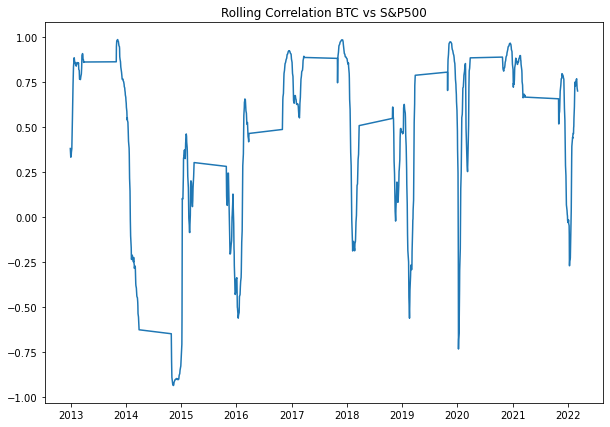

In [10]:
import statistics
rollingCorr = []
w =50
for t in range(len(CorrData)-w):
    subSer = df3['Market Price'][t:t+w]
    corr_matrix = np.corrcoef(CorrData['Market Price'][t:t+w], CorrData['Adj Close'][t:t+w])
    CorrData.loc[t+w,'RollingCorr'] = corr_matrix[0][1]
    #rollingVol.append(vol_i)


fig, ax1 = plt.subplots(figsize=(10,7))
plt.plot(CorrData['TimeStamp'], CorrData['RollingCorr'])
ax1.set(title="Rolling Correlation BTC vs S&P500")
plt.show()

In [11]:
df3['Market Price']
MarketPrices = df3['Market Price']
ExogVariables = df3[['Difficulty','HashRate','MinerRevenue(BTC)']]
ExogVariables.index = pd.DatetimeIndex(df3.TimeStamp)
ExogVariables = ExogVariables.resample('BMS', convention='end').asfreq().bfill()
MarketPrices.index = pd.DatetimeIndex(df3.TimeStamp)
MarketPrices = MarketPrices.resample('BMS', convention='end').asfreq().bfill()
MarketPrices
ExogVariables

,Difficulty,HashRate,MinerRevenue(BTC)
TimeStamp,,,
2012-03-01,3.304356e+06,2.217516e+01,7972.938893
2012-04-02,3.304356e+06,2.217516e+01,7972.938893
2012-05-01,3.304356e+06,2.217516e+01,7972.938893
2012-06-01,3.304356e+06,2.217516e+01,7972.938893
2012-07-02,3.304356e+06,2.217516e+01,7972.938893
...,...,...,...
2021-11-01,2.165934e+13,1.593504e+08,939.144232
2021-12-01,2.233566e+13,1.521127e+08,882.514278
2022-01-03,2.427233e+13,1.689218e+08,886.588940


<b> Hamilton (1989) switching model </b>

The model can be written as:


$ y_{t} = a_{S_t} + x_t\beta_{S_t} + \phi_{1, S_t}
        (y_{t-1} - a_{S_{t-1}} - x_{t-1}) \beta_{S_{t-1}} + \dots +
        \phi_{p, S_t} (y_{t-p} - a_{S_{t-p}} - x_{t-p}) \beta_{S_{t-p}} +
        \varepsilon_t \\
        \varepsilon_t \sim N(0, \sigma_{S_t}^2)$

    i.e. the model is an autoregression with where the autoregressive
    coefficients, the mean of the process (possibly including trend or
    regression effects) and the variance of the error term may be switching
    across regimes.

    The `trend` is accommodated by prepending columns to the `exog` array. Thus
    if `trend='c'`, the passed `exog` array should not already have a column of
    ones.

    References
    ----------
    Kim, Chang-Jin, and Charles R. Nelson. 1999.
    "State-Space Models with Regime Switching:
    Classical and Gibbs-Sampling Approaches with Applications".
    MIT Press Books. The MIT Press.
    """

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Markov Switching Model Results                         
================================================================================
Dep. Variable:             Market Price   No. Observations:                  117
Model:             MarkovAutoregression   Log Likelihood               -1078.354
Date:                  Wed, 09 Mar 2022   AIC                           2174.708
Time:                          08:24:16   BIC                           2199.567
Sample:                      03-01-2012   HQIC                          2184.801
                           - 03-01-2022                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.021e+04   3.33e-10   3.06e+13      0.000    1.02e+04    1.02e+04
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.036e+04   1.53e-07   6.76e+10      0.000    1.04e+04    1.04e+04
                           Non-switching parameters                           
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.906e+06   1.26e-13   4.68e+19      0.000    5.91e+06    5.91e+06
ar.L1          1.4570      0.099     14.725      0.000       1.263       1.651
ar.L2         -0.5439      0.180     -3.027      0.002      -0.896      -0.192
ar.L3          0.2480      0.182      1.359      0.174      -0.110       0.605
ar.L4         -0.1790      0.110     -1.620      0.105      -0.395       0.038
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        1.0000        nan        nan        nan         nan         nan
p[1->0]     1.434e-15        nan        nan        nan         nan         nan
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
[2] Covariance matrix is singular or near-singular, with condition number 1.82e+23. Standard errors may be unstable.
"""

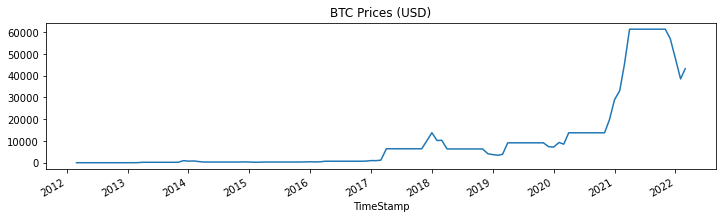

In [12]:
from datetime import datetime
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# NBER recessions
from pandas_datareader.data import DataReader

'''
MarketPrices = df3['Market Price']
MarketPrices.index = pd.DatetimeIndex(df3.TimeStamp)
'''
# Plot the data
MarketPrices.plot(title="BTC Prices (USD)", figsize=(12, 3))

mod_hamilton = sm.tsa.MarkovAutoregression(
    MarketPrices, k_regimes=2, order=4, switching_ar=False
)
res_hamilton = mod_hamilton.fit()
#res_hamilton.filtered_marginal_probabilities
res_hamilton.summary()

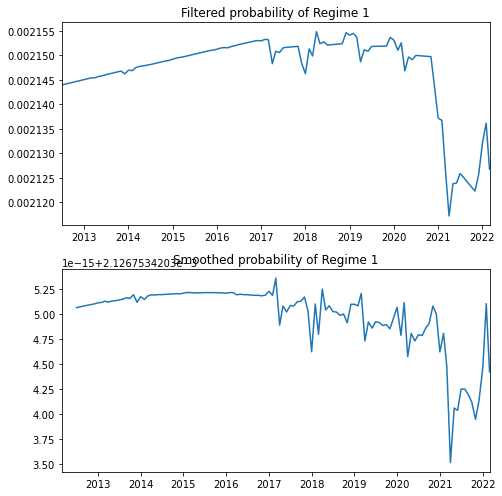

In [13]:
fig, axes = plt.subplots(2, figsize=(7, 7))
ax = axes[0]
ax.plot(res_hamilton.filtered_marginal_probabilities[0])

#ax.fill_between(MarketPrices.index, 0, 1, where=usrec["USREC"].values, color="k", alpha=0.1)
ax.set_xlim(MarketPrices.index[4], MarketPrices.index[-1])
ax.set(title="Filtered probability of Regime 1")

ax = axes[1]
ax.plot(res_hamilton.smoothed_marginal_probabilities[0])
#ax.fill_between(usrec.index, 0, 1, where=usrec["USREC"].values, color="k", alpha=0.1)
ax.set_xlim(MarketPrices.index[0], MarketPrices.index[-1])
ax.set(title="Smoothed probability of Regime 1")

fig.tight_layout()

Markov Regression 



<class 'statsmodels.iolib.summary.Summary'>
"""
                         Markov Switching Model Results                         
================================================================================
Dep. Variable:             Market Price   No. Observations:                  117
Model:             MarkovAutoregression   Log Likelihood               -1078.354
Date:                  Wed, 09 Mar 2022   AIC                           2174.708
Time:                          08:24:20   BIC                           2199.567
Sample:                      03-01-2012   HQIC                          2184.801
                           - 03-01-2022                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.021e+04   3.33e-10   3.06e+13      0.000    1.02e+04    1.02e+04
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.036e+04   1.53e-07   6.76e+10      0.000    1.04e+04    1.04e+04
                           Non-switching parameters                           
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.906e+06   1.26e-13   4.68e+19      0.000    5.91e+06    5.91e+06
ar.L1          1.4570      0.099     14.725      0.000       1.263       1.651
ar.L2         -0.5439      0.180     -3.027      0.002      -0.896      -0.192
ar.L3          0.2480      0.182      1.359      0.174      -0.110       0.605
ar.L4         -0.1790      0.110     -1.620      0.105      -0.395       0.038
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        1.0000        nan        nan        nan         nan         nan
p[1->0]     1.434e-15        nan        nan        nan         nan         nan
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
[2] Covariance matrix is singular or near-singular, with condition number 1.82e+23. Standard errors may be unstable.
"""

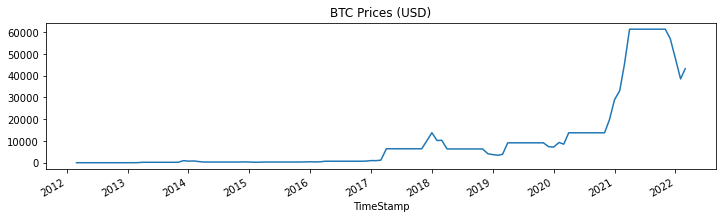

In [14]:
from datetime import datetime
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# NBER recessions
from pandas_datareader.data import DataReader


# Plot the data
MarketPrices.plot(title="BTC Prices (USD)", figsize=(12, 3))

msdr_model = sm.tsa.MarkovRegression(MarketPrices, k_regimes=2, trend='c',exog=ExogVariables['MinerRevenue(BTC)'],switching_variance = True)
msdr_model_results = mod_hamilton.fit(iter=1000)
#res_hamilton.filtered_marginal_probabilities
msdr_model_results.summary()

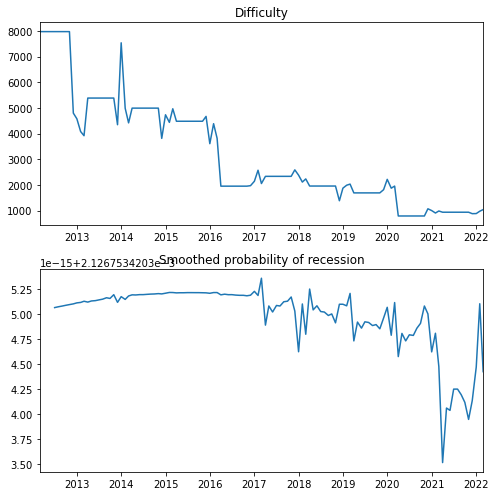

In [15]:
fig, axes = plt.subplots(2, figsize=(7, 7))
ax = axes[0]
ax.plot(ExogVariables['MinerRevenue(BTC)'])
ax.set_xlim(MarketPrices.index[0], MarketPrices.index[-1])
ax.set(title="Difficulty")

ax = axes[1]
ax.plot(msdr_model_results.smoothed_marginal_probabilities[0])
ax.set_xlim(MarketPrices.index[0], MarketPrices.index[-1])
ax.set(title="Smoothed probability of recession")

fig.tight_layout()

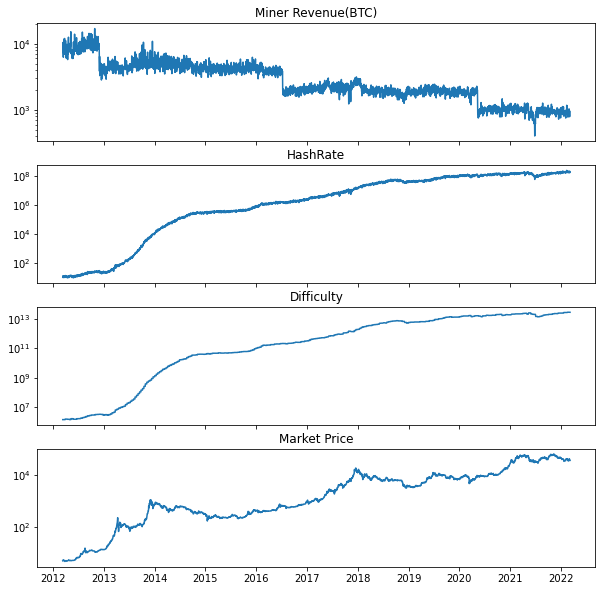

In [16]:
    fig,axs = plt.subplots(4,sharex=True,figsize=(10,10))
    
    axs[0].plot(df3['TimeStamp'],df3['MinerRevenue(BTC)'],label='MinerRevenue')
    axs[0].set_title('Miner Revenue(BTC)')
    axs[0].set_yscale('log')
    
    axs[1].plot(df3['TimeStamp'],df3['HashRate'],label='HashRate')
    axs[1].set_title('HashRate')
    axs[1].set_yscale('log')
    
    axs[2].plot(df3['TimeStamp'],df3['Difficulty'],label='Difficulty')
    axs[2].set_title('Difficulty')
    axs[2].set_yscale('log')
    
    axs[3].plot(df3['TimeStamp'],df3['Market Price'],label='Market Price')
    axs[3].set_title('Market Price')
    axs[3].set_yscale('log')


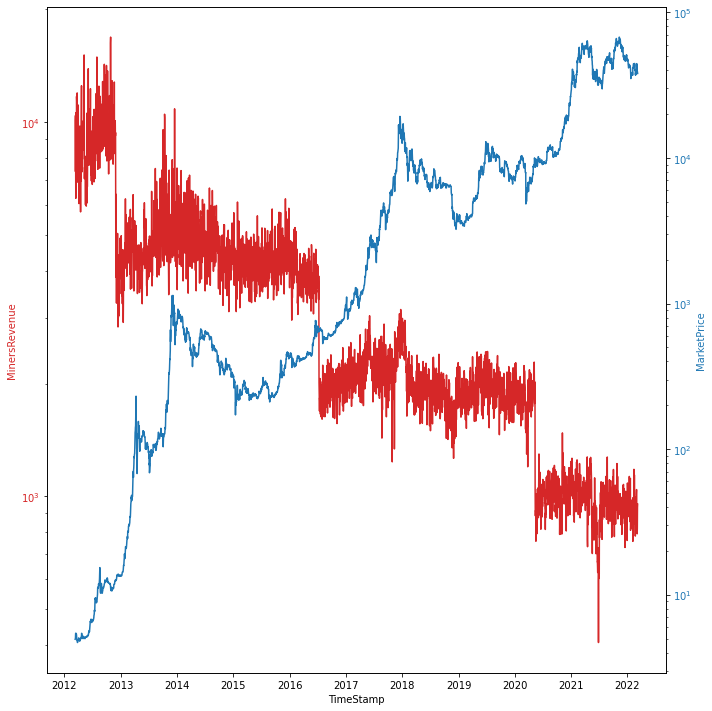

In [17]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('MinersRevenue', color=color)
ax1.plot(df3['TimeStamp'],df3['MinerRevenue(BTC)'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

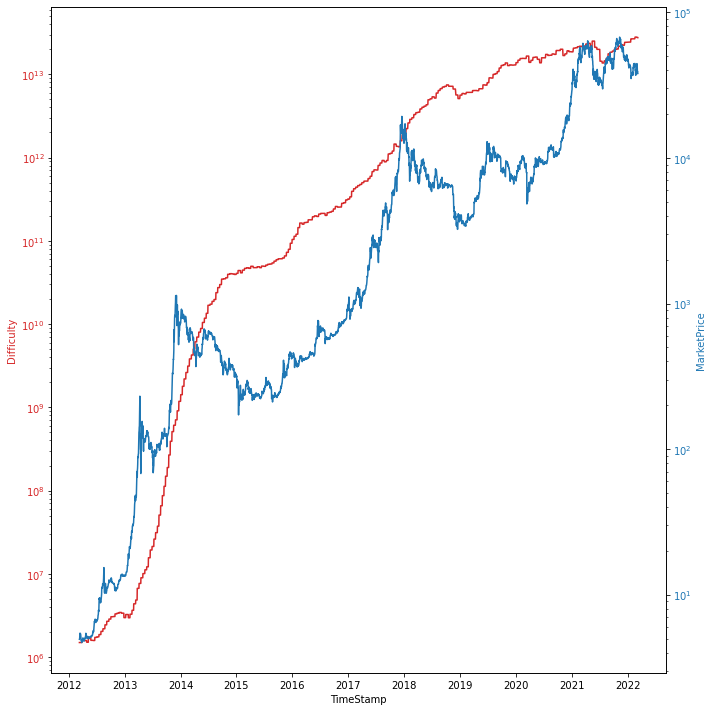

In [18]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('Difficulty', color=color)
ax1.plot(df3['TimeStamp'],df3['Difficulty'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

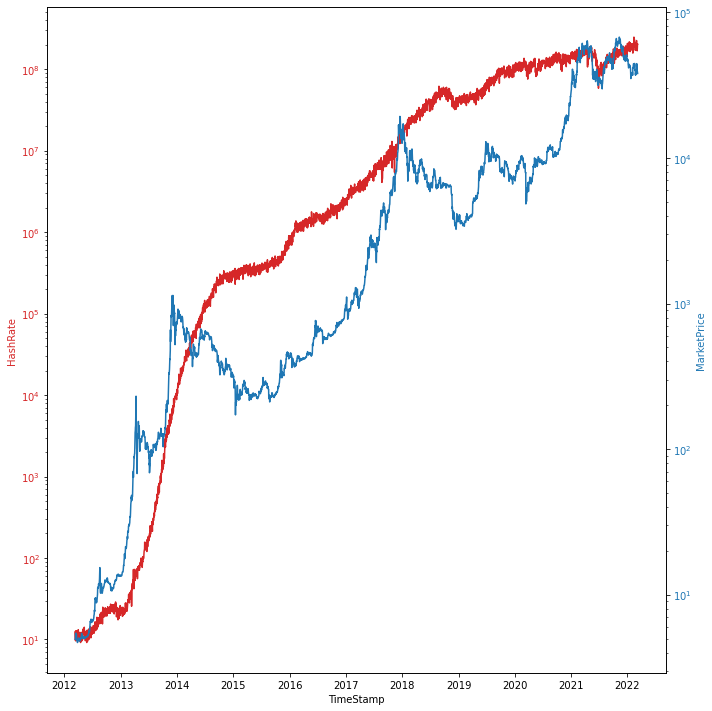

In [19]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('HashRate', color=color)
ax1.plot(df3['TimeStamp'],df3['HashRate'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

<b> Rolling Window Vol vs Timestamp </b>

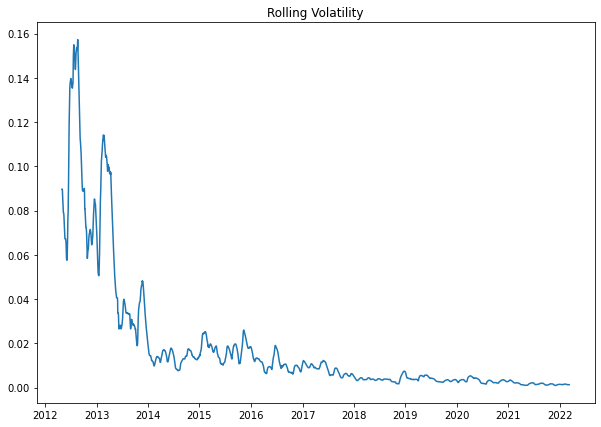

In [71]:
import statistics

rollingVol = []
w = 50       #Rolling Window Length
for t in range(len(df3)-w):
    subSer = df3['Market Price'][t:t+ w]
    mean_i = np.mean(subSer)
    vol_i = (np.sum((subSer - mean_i)**2) / len(subSer))**0.5
    df3.loc[t+w,'RollingVol'] = np.sqrt(vol_i)/mean_i
    #rollingVol.append(vol_i)

df3

fig, ax1 = plt.subplots(figsize=(10,7))
plt.plot(df3['TimeStamp'], df3['RollingVol'])
ax1.set(title="Rolling Volatility")
plt.show()

<b> Finding Optimal Pivot Date based on $R^{2}$ diff between regimes  </b>

In [67]:
 from datetime import datetime,timedelta
#FitScaler
def FitScaler(data):
    scaler = StandardScaler()
    scaler.fit(data)
    # scale data set
    Xt = scaler.transform(data)
    Scaled_Xt = pd.DataFrame(Xt, columns =data.columns)

    X = sm.add_constant(Scaled_Xt)
    return X

#Finding Optimal Pivot Point
maxRsqaurediff = 0
OptimalPivotDate = datetime.strptime( "2016-1-1", '%Y-%m-%d')
pivot_date = datetime.strptime( "2016-1-1", '%Y-%m-%d')

firstRegimeRsquaredList = []
secondRegimeRsquaredList = []
pivotDateList = []

while(pivot_date < datetime.strptime( "2021-11-30", '%Y-%m-%d')):
    pivotDateList.append(pivot_date)  
    firstRegime = df3.loc[(df3["TimeStamp"] < pivot_date) & (df3["TimeStamp"] > (pivot_date - timedelta(days=200)))]
    firstRegime.reset_index(drop=True)
    
    secondRegime = df3.loc[(df3["TimeStamp"] > pivot_date) & (df3["TimeStamp"] < (pivot_date + timedelta(days=200)))]
    secondRegime.reset_index(drop=True)

    firstX = np.log(firstRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
    firstY = np.log(firstRegime['Market Price']).reset_index(drop=True)

    secondX = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
    secondY = np.log(secondRegime['Market Price'].reset_index(drop=True))

    firstScaledX = FitScaler(firstX)
    res = sm.OLS(firstY, firstScaledX).fit()
    firstRegimeRsquared = res.rsquared
    firstRegimeRsquaredList.append(firstRegimeRsquared)
    
    secondScaledX = FitScaler(secondX)
    res = sm.OLS(secondY, secondScaledX).fit()
    secondRegimeRsquared = res.rsquared
    secondRegimeRsquaredList.append(secondRegimeRsquared)
    
    Rsquarediff = firstRegimeRsquared - secondRegimeRsquared
    if Rsquarediff >maxRsqaurediff:
        OptimalPivotDate = pivot_date
        maxRsqaurediff = Rsquarediff
   # print(pivot_date,":" ,Rsquarediff)
    pivot_date =  pivot_date + timedelta(days=1)
   
    
print("Optimal Regime Shift Date:", OptimalPivotDate)

Optimal Regime Shift Date: 2019-08-22 00:00:00


In [79]:
pivot_date

datetime.datetime(2019, 8, 22, 0, 0)

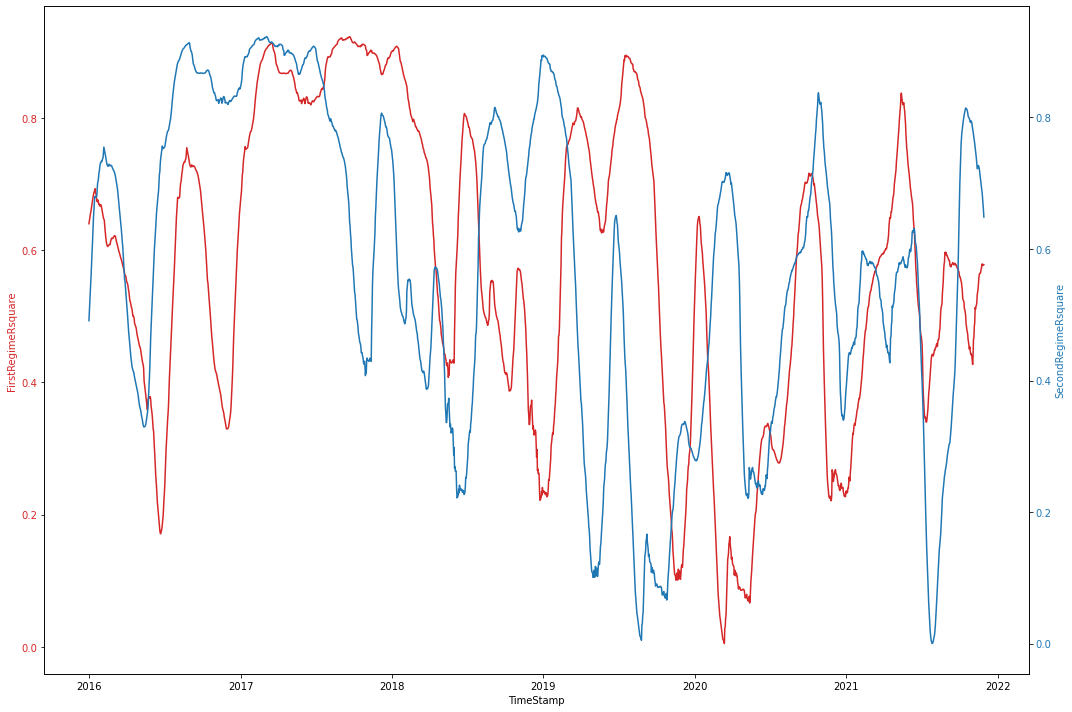

In [68]:
RsquareDf = pd.DataFrame(
    {'PivotDate': pivotDateList,
     'FirstRegimeRsquare': firstRegimeRsquaredList,
     'SecondRegimeRsquare':secondRegimeRsquaredList
    })

fig, ax1 = plt.subplots(figsize=(15,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('FirstRegimeRsquare', color=color)
ax1.plot(RsquareDf['PivotDate'],RsquareDf['FirstRegimeRsquare'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
#ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('SecondRegimeRsquare', color=color)  # we already handled the x-label with ax1
ax2.plot(RsquareDf['PivotDate'],RsquareDf['SecondRegimeRsquare'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
#ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [72]:
#Dividing data into regimes
pivot_date =  OptimalPivotDate
firstRegime = df3.loc[df3["TimeStamp"] < pivot_date]

firstRegime

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
0,2012-03-11 00:00:00,3.664537e+04,1.496979e+06,4.95,9.897223e+00,7403.105367,NaN
1,2012-03-12 00:00:00,5.031774e+04,1.496979e+06,4.98,1.257617e+01,10103.963295,NaN
2,2012-03-13 00:00:00,5.279293e+04,1.496979e+06,5.07,1.131111e+01,10412.807616,NaN
3,2012-03-14 00:00:00,4.582820e+04,1.496979e+06,5.42,1.026930e+01,8455.386978,NaN
4,2012-03-15 00:00:00,3.408271e+04,1.496979e+06,5.45,9.599562e+00,6253.708599,NaN
...,...,...,...,...,...,...,...
2715,2019-08-17 01:00:00,1.681876e+07,9.985348e+12,10359.44,6.353592e+07,1623.519937,0.002697
2716,2019-08-18 01:00:00,1.649732e+07,1.001680e+13,10214.52,6.274016e+07,1615.085525,0.002704
2717,2019-08-19 01:00:00,2.251242e+07,1.018349e+13,10317.60,8.251450e+07,2181.943108,0.002678
2718,2019-08-20 01:00:00,2.138194e+07,1.018349e+13,10917.26,7.745227e+07,1958.544619,0.002667


In [73]:
#Generating Correlation Matrix for first Regime
Corr_Matrix = firstRegime[firstRegime.columns.drop(['TimeStamp'])].corr()
Corr_Matrix.style.background_gradient(cmap='coolwarm').set_precision(4)

,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
MinerRevenue,1.0000,0.6187,0.9726,0.6418,-0.4367,-0.3778
Difficulty,0.6187,1.0000,0.7378,0.9927,-0.4971,-0.3551
Market Price,0.9726,0.7378,1.0000,0.7493,-0.5024,-0.3916
HashRate,0.6418,0.9927,0.7493,1.0000,-0.4913,-0.3551
MinerRevenue(BTC),-0.4367,-0.4971,-0.5024,-0.4913,1.0000,0.7163
RollingVol,-0.3778,-0.3551,-0.3916,-0.3551,0.7163,1.0000


In [74]:
secondRegime = df3.loc[df3["TimeStamp"] >= pivot_date]
secondRegime.reset_index(drop=True)

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
0,2019-08-22 01:00:00,1.824479e+07,1.018349e+13,10129.40,7.137758e+07,1801.171515,0.002665
1,2019-08-23 01:00:00,2.030322e+07,1.018349e+13,10111.98,7.745227e+07,2007.837893,0.002677
2,2019-08-24 01:00:00,2.091319e+07,1.018349e+13,10405.81,8.099583e+07,2009.761004,0.002664
3,2019-08-25 01:00:00,2.002305e+07,1.018349e+13,10143.80,7.846471e+07,1973.920446,0.002667
4,2019-08-26 01:00:00,1.805160e+07,1.018349e+13,10135.06,6.935268e+07,1781.104320,0.002676
...,...,...,...,...,...,...,...
925,2022-03-04 00:00:00,3.633393e+07,2.755033e+13,42464.40,1.903653e+08,855.632626,0.001308
926,2022-03-05 00:00:00,3.104514e+07,2.755033e+13,39141.25,1.684527e+08,793.156667,0.001302
927,2022-03-06 00:00:00,3.234770e+07,2.755033e+13,39399.58,1.794090e+08,821.016357,0.001301
928,2022-03-07 00:00:00,3.583683e+07,2.755033e+13,38407.69,2.026911e+08,933.063882,0.001297


In [75]:
#Generating Correlation Matrix for second Regime
Corr_Matrix = secondRegime[secondRegime.columns.drop(['TimeStamp'])].corr()
Corr_Matrix.style.background_gradient(cmap='coolwarm').set_precision(4)

,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
MinerRevenue,1.0000,0.6061,0.9606,0.6809,-0.3924,-0.6604
Difficulty,0.6061,1.0000,0.7077,0.8706,-0.6648,-0.5876
Market Price,0.9606,0.7077,1.0000,0.6823,-0.5918,-0.7305
HashRate,0.6809,0.8706,0.6823,1.0000,-0.4734,-0.5619
MinerRevenue(BTC),-0.3924,-0.6648,-0.5918,-0.4734,1.0000,0.5896
RollingVol,-0.6604,-0.5876,-0.7305,-0.5619,0.5896,1.0000


<b> First Regime - Model Fit </b>

In [76]:
x = np.log(firstRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
y = np.log(firstRegime['Market Price'])

# create and fit scaler
scaler = StandardScaler()
scaler.fit(x)
# scale data set
Xt = scaler.transform(x)
Scaled_Xt = pd.DataFrame(Xt, columns =x.columns)

X = sm.add_constant(Scaled_Xt)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           Market Price   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     7781.
Date:                Wed, 09 Mar 2022   Prob (F-statistic):               0.00
Time:                        09:49:54   Log-Likelihood:                -2786.0
No. Observations:                2720   AIC:                             5580.
Df Residuals:                    2716   BIC:                             5604.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.2919      0.01

<b> Second Regime - Model Fit </b>

In [78]:
#x = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
x = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
y = np.log(secondRegime['Market Price'].reset_index(drop=True))

# create and fit scaler
scaler = StandardScaler()
scaler.fit(x)
# scale data set
Xt = scaler.transform(x)
Scaled_Xt = pd.DataFrame(Xt, columns =x.columns)
Scaled_Xt

X = sm.add_constant(Scaled_Xt)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           Market Price   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     548.4
Date:                Wed, 09 Mar 2022   Prob (F-statistic):          8.78e-205
Time:                        09:51:22   Log-Likelihood:                -642.62
No. Observations:                 930   AIC:                             1293.
Df Residuals:                     926   BIC:                             1313.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.9071      0.01

 Regime Shift Tests:
 
 Miner Revenue in BTC
~Running Window 90 day Vol plot - identify pivot


Correlation btc vs S&P
t-test - rolling windows
ADF test - identify point of mean reversion

Explore Additional features:
 HHI? Concentration 
 
 Explore Logistic or other non Linear Regression Techniques

find arbitrary point  - rolling regression biggest R2 diff between regimes
new regime -> check effect of US interest rates, equity correlation